# Project 6: Sampling Methods
Sophia Klymchuk and Devin Zhang

The first part of the sampling methods project is to perform rejection sampling  to draw samples from a Gaussian mixture model.

Use the same mixture model from the EM project (1-D only), and I suggest using regular normal RV for the proposal distribution. Draw samples using this method and plot a histogram of the generated samples against your GMM.

Part two of the sampling methods mini-project is to re-do your linear regression project using MCMC to find an estimate for the weights.

Reuse your project 2 to generate the same training data. Just do this for 25 training samples

Use Equation 3.10 as the likelihood function, to be used with the training samples you generated. You may select any distribution you want for the prior on the weights, and recall that the posterior density on the weights w is proportional to the likelihood x prior. Note, you'll want to take the log of the posterior to keep this numerically stable

Use the Metropolis algorithm as defined in equation 11.33 to compute an estimate of the weights




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import seaborn as sns

## Part 1

Generate 1D data from mixture of 3 Gaussians

In [ ]:
def generate_1d_data(n=10000):
    true_means = [-3, 0, 4]
    true_vars = [0.5, 1.0, 0.8]
    true_pi = [0.3, 0.4, 0.3]   # Mixing Coefficients

    k = np.random.choice(3, size=n, p=true_pi)
    data = np.array([np.random.normal(true_means[i], np.sqrt(true_vars[i])) for i in k])
    return data

GMM PDF

In [ ]:
def gmm_pdf(x, means, vars, weights):
    # Calculates GMM probability density at the input position x
    pdf = 0
    for mean, var, weight in zip(means, vars, weights):
        pdf += weight * norm.pdf(x, mean, np.sqrt(var)) # Weighted sum of each Gaussian density
    return pdf

Rejection Sampling

In [ ]:
def rejection_sampling(n_samples, means, vars, weights):
    # Proposal distribution, wide enough to cover all clusters
    proposal_mean = 0
    proposal_std = 5.0

    # Find scaling factor, M, so that M * proposal(x) >= target(x) for all x.
    x_range = np.linspace(-10, 10, 10000)
    M = np.max(gmm_pdf(x_range, means, vars, weights) / norm.pdf(x_range, proposal_mean, proposal_std))

    samples = []
    while len(samples) < n_samples:
        x = norm.rvs(proposal_mean, proposal_std) # makes the sampling random
        u = np.random.uniform(0, 1) # makes the accept/reject random

        target_density = gmm_pdf(x, means, vars, weights)
        proposal_density = norm.pdf(x, proposal_mean, proposal_std)
        acceptance_prob = target_density / (M * proposal_density)

        if u < acceptance_prob:
            samples.append(x)

    return np.array(samples)

Execute

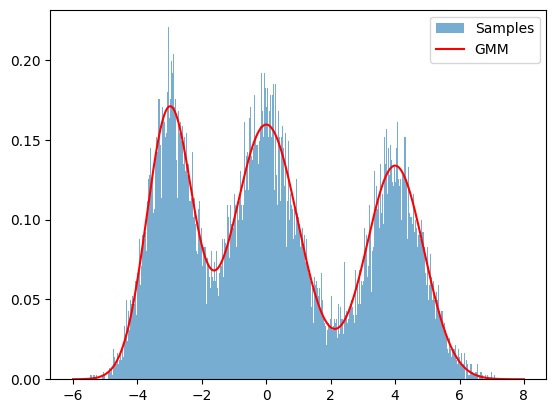

In [ ]:
means = [-3, 0, 4]
vars = [0.5, 1.0, 0.8]
weights = [0.3, 0.4, 0.3]

samples = rejection_sampling(20000, means, vars, weights)

plt.hist(samples, bins=600, density=True, alpha=0.6, label='Samples')
x = np.linspace(-6, 8, 5000)
plt.plot(x, gmm_pdf(x, means, vars, weights), 'r-', label='GMM')
plt.legend()
plt.show()

## Part 2

Generate Training Data

In [ ]:
lower_x_bound, upper_x_bound = -1, 1
true_slope, true_intercept = 0.5, -0.3 # y = 0.5x - 0.3
true_noise_std = 0.2 # This is the noise that gets added when we draw a target observation
true_noise_var = true_noise_std**2
true_noise_beta = 1 / true_noise_var

mu_0 = np.array([0.0, 0.0])
alpha_0 = 2.0
s_0 = (1/alpha_0) * np.eye(2)

# Generate 25 training samples
num_observations = 25
x_obs_history, t_obs_history = [], []

for n in range(num_observations):
    x_obs = np.random.uniform(lower_x_bound, upper_x_bound)
    true_y = true_slope * x_obs + true_intercept
    t_obs = true_y + np.random.normal(0.0, true_noise_std)
    x_obs_history.append(x_obs)
    t_obs_history.append(t_obs)

x_data = np.array(x_obs_history)
t_data = np.array(t_obs_history)

MCMC using Metropolis Algorithm

Helper functions

In [ ]:
def phi(x):
    basis = np.array([1.0, x])
    return basis

def log_likelihood(w, x_data, t_data, beta):
    # Eq 3.10
    log_lik = 0
    for n in range(len(x_data)):
        phi_xn = phi(x_data[n])
        mean = np.dot(w, phi_xn)
        variance = 1.0 / beta
        std_dev = np.sqrt(variance)
        log_prob = norm.logpdf(t_data[n], loc=mean, scale=std_dev)
        log_lik += log_prob
    return log_lik

def log_prior(w, alpha):
    mean = np.zeros(2)
    cov = (1.0 / alpha) * np.eye(2)
    std_dev_0 = np.sqrt(cov[0,0])
    std_dev_1 = np.sqrt(cov[1,1])
    log_prob_w0 = norm.logpdf(w[0], loc=mean[0], scale=std_dev_0)
    log_prob_w1 = norm.logpdf(w[1], loc=mean[1], scale=std_dev_1)
    log_pri = log_prob_w0 + log_prob_w1
    return log_pri

def log_posterior(w, x_data, t_data, beta, alpha):
    log_lik = log_likelihood(w, x_data, t_data, beta)
    log_pri = log_prior(w, alpha)
    log_post = log_lik + log_pri
    return log_post

In [ ]:
def metropolis_mcmc(x_data, t_data, beta, alpha, n_samples=10000, proposal_std=0.1):
    w = np.array([0.0, 0.0])
    samples = []

    for i in range(n_samples):
        # Propose new weights from q(w*|w^(τ))
        noise = np.random.normal(0, proposal_std, size=2) # random walk
        w_proposed = w + noise

        # Compute acceptance probability A(w*, w^(τ))
        log_p_current = log_posterior(w, x_data, t_data, beta, alpha)
        log_p_proposed = log_posterior(w_proposed, x_data, t_data, beta, alpha)
        log_ratio = log_p_proposed - log_p_current
        acceptance_prob = min(1.0, np.exp(log_ratio)) # Eq 11.33

        # Accept or reject
        u = np.random.uniform(0, 1)
        if u < acceptance_prob:
            w = w_proposed

        w_copy = w.copy()
        samples.append(w_copy)

    samples_array = np.array(samples)
    return samples_array

Execute

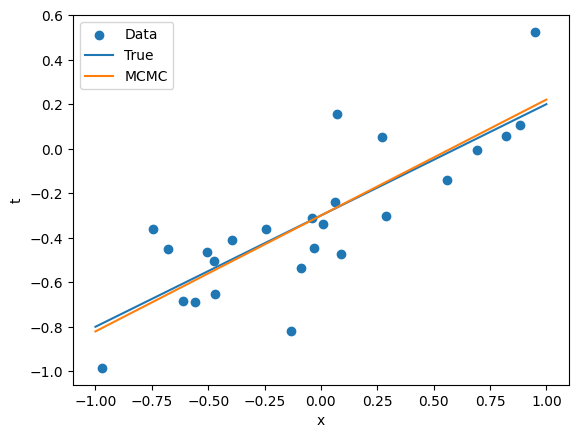

Estimated slope: 0.52
Estimated intercept: -0.30
True slope: 0.50
True intercept: -0.30


In [ ]:
samples = metropolis_mcmc(x_data, t_data, true_noise_beta, alpha_0, n_samples=1000)
w_mcmc = np.mean(samples, axis=0)

# Data and fitted line
x_plot = np.linspace(-1, 1, 100)
plt.scatter(x_data, t_data, label='Data')
plt.plot(x_plot, true_intercept + true_slope * x_plot, label='True')
plt.plot(x_plot, w_mcmc[0] + w_mcmc[1] * x_plot, label='MCMC')
plt.xlabel('x')
plt.ylabel('t')
plt.legend()
plt.show()

print(f"Estimated slope: {w_mcmc[1]:.2f}")
print(f"Estimated intercept: {w_mcmc[0]:.2f}")
print(f"True slope: {true_slope:.2f}")
print(f"True intercept: {true_intercept:.2f}")

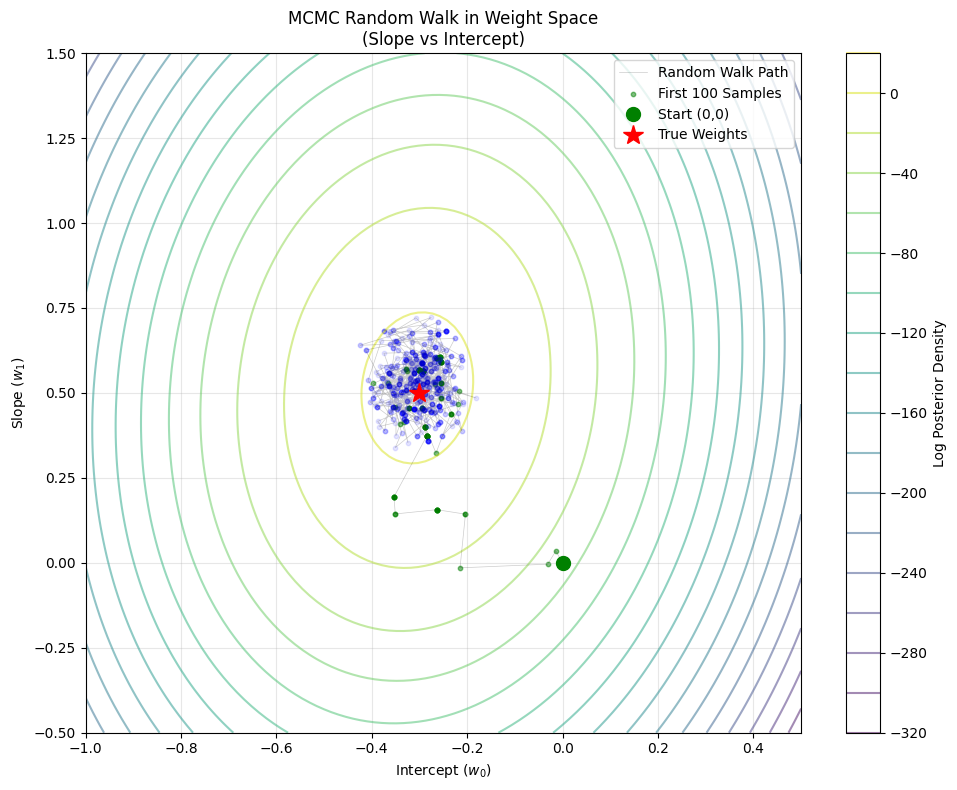

In [ ]:
# Plot the MCMC Path Over the w0 w1 plane
# --- 4. VISUALIZATION OF THE PATH ---
plt.figure(figsize=(10, 8))

# A. Generate the Background Contour (The Landscape)
# Create a grid of w0 (intercept) and w1 (slope) values
w0_vals = np.linspace(-1, 0.5, 100)
w1_vals = np.linspace(-0.5, 1.5, 100)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
Z = np.zeros_like(W0)

# Calculate log_posterior for every point on the grid
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        w_temp = np.array([W0[i, j], W1[i, j]])
        Z[i, j] = log_posterior(w_temp, x_data, t_data, true_noise_beta, alpha_0)

# Plot the contours
plt.contour(W0, W1, Z, levels=20, cmap='viridis', alpha=0.5)
plt.colorbar(label='Log Posterior Density')

# B. Plot the MCMC Path
# Plot the lines connecting the dots (The Walk)
plt.plot(samples[:, 0], samples[:, 1], 'k-', alpha=0.2, linewidth=0.5, label='Random Walk Path')

# Plot the actual samples (The Footsteps)
# We plot the first few in green (start) and later ones in blue to show progression
plt.scatter(samples[:100, 0], samples[:100, 1], s=10, c='green', alpha=0.5, label='First 100 Samples')
plt.scatter(samples[100:, 0], samples[100:, 1], s=10, c='blue', alpha=0.1)

# C. Mark Special Points
plt.plot(samples[0, 0], samples[0, 1], 'go', markersize=10, label='Start (0,0)')
plt.plot(true_intercept, true_slope, 'r*', markersize=15, label='True Weights')

plt.title(f'MCMC Random Walk in Weight Space\n(Slope vs Intercept)')
plt.xlabel('Intercept ($w_0$)')
plt.ylabel('Slope ($w_1$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()